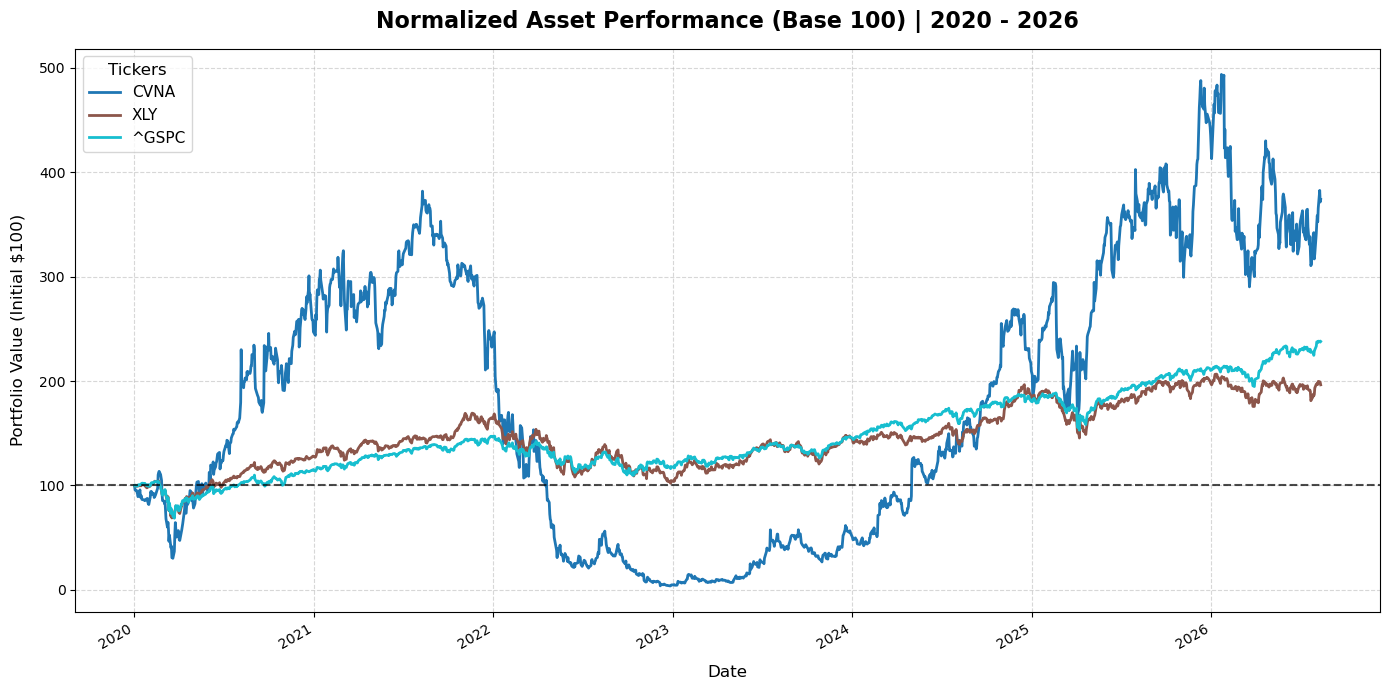

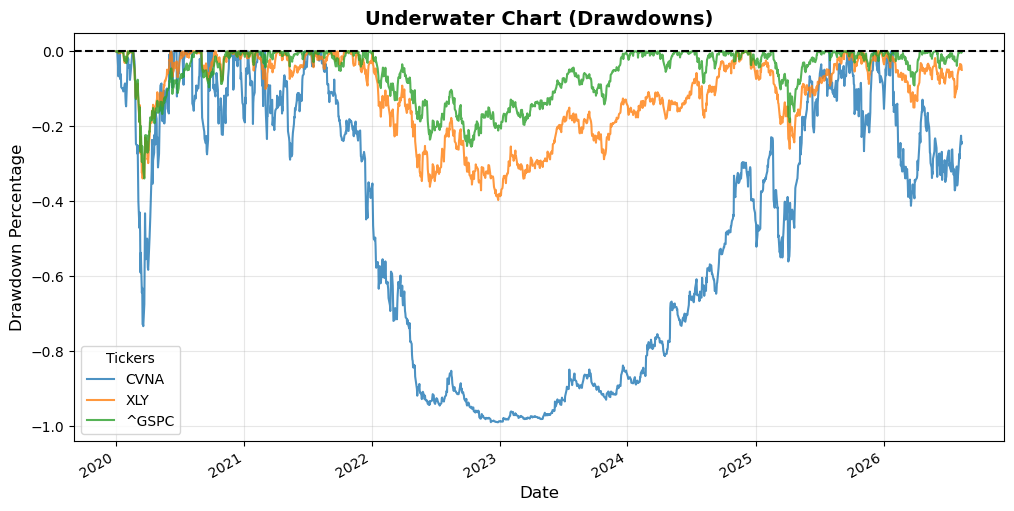


=== Annual Returns (Log) ===
Ticker
CVNA     20.02%
XLY      10.24%
^GSPC    13.15%
dtype: object

=== Excess Returns (vs S&P 500) ===
Excess Return CVNA vs S&P 500: 6.86%
Excess Return XLY vs S&P 500:  -2.91%

=== Maximum Drawdowns (Worst-case Drop) ===
CVNA:    -98.99%
S&P 500: -33.92%
XLY:     -39.67%

=== Investment Memo: Carvana (CVNA) ===

During the examined period, CVNA recorded an annualized (log) return of
20.02%, with an excess return of 6.86%
against the S&P 500.

However, the stock exhibits extreme volatility, with a Maximum Drawdown
reaching -98.99%. Due to the risk of near-total
loss of the initial capital (severe path-dependency), the stock is
deemed prohibitive for conservative portfolios and is strictly recommended
only for speculative trading with minimal position sizing.

(Note: the excess return is a naive/raw return differential, not a
risk-adjusted CAPM alpha — this requires beta calculation, covered in upcoming modules.)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

# ==========================================
# 1. CONSTANTS (Project Settings)
# ==========================================
TICKER = ["CVNA"]
BENCHMARK = ["^GSPC"]
ETF = ["XLY"]
SUBJECTS = TICKER + BENCHMARK + ETF

START_DATE = "2020-01-01"
END_DATE = datetime.date.today()
TRADING_DAYS = 252

# ==========================================
# 2. DATA PIPELINE FUNCTIONS
# ==========================================
def get_clean_data(tickers: list, start: str, end: datetime.date) -> pd.DataFrame:
    """ Downloads data, removes missing values, and performs quality checks. """
    data = yf.download(tickers, start=start, end=end, progress=False)["Close"]
    data = data.dropna()

    # Safety (Assertions) - Demonstrates Quant Engineering mindset
    assert data.index.is_monotonic_increasing, "Error: Data is not chronologically sorted!"
    assert data.isna().sum().sum() == 0, "Error: NaN values found!"

    return data


def plot_normalized_performance(data: pd.DataFrame):
    """ Calculates Base 100 and generates the Institutional Performance Chart. """
    normalized_data = (data / data.iloc[0]) * 100
    ax = normalized_data.plot(figsize=(14, 7), linewidth=2, colormap="tab10")
    ax.axhline(100, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

    plt.title("Normalized Asset Performance (Base 100) | 2020 - 2026", fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Date", fontsize=12, labelpad=10)
    plt.ylabel("Portfolio Value (Initial $100)", fontsize=12, labelpad=10)
    plt.legend(title="Tickers", fontsize=11, title_fontsize=12, loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def compute_returns_metrics(data: pd.DataFrame) -> tuple:
    """ Computes returns and Excess Return. """
    daily_simple_returns = data.pct_change().dropna()
    daily_log_returns = np.log(data / data.shift(1)).dropna()

    annual_log_return = daily_log_returns.mean() * TRADING_DAYS

    # Excess Return (naive, not risk-adjusted CAPM alpha)
    excess_return_sp500 = annual_log_return["CVNA"] - annual_log_return["^GSPC"]
    excess_return_xly = annual_log_return["XLY"] - annual_log_return["^GSPC"]

    return daily_simple_returns, annual_log_return, excess_return_sp500, excess_return_xly


def compute_and_plot_drawdowns(daily_simple_returns: pd.DataFrame) -> pd.Series:
    """ Calculates Max Drawdown and generates the Underwater Chart. """
    wealth_index = (1 + daily_simple_returns).cumprod()
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks) / previous_peaks

    max_drawdown = drawdowns.min()

    # Underwater Chart
    # We use actual column names (drawdowns.columns) instead of a 
    # hardcoded list, ensuring the legend always matches correctly regardless
    # of the column order returned by yf.download().
    drawdowns.plot(figsize=(12, 6), linewidth=1.5, alpha=0.8)
    plt.axhline(0, color="black", linestyle="--", linewidth=1.5)

    plt.title("Underwater Chart (Drawdowns)", fontsize=14, fontweight="bold")
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Drawdown Percentage", fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(drawdowns.columns, title="Tickers")
    plt.show()

    return max_drawdown


def print_report(annual_log_return: pd.Series, excess_return_sp500: float,
                 excess_return_xly: float, max_drawdown: pd.Series):
    """ Prints the final analysis report, fully linked to the computed data. """
    print("\n=== Annual Returns (Log) ===")
    print((annual_log_return * 100).map("{:.2f}%".format))

    print("\n=== Excess Returns (vs S&P 500) ===")
    print(f"Excess Return CVNA vs S&P 500: {excess_return_sp500 * 100:.2f}%")
    print(f"Excess Return XLY vs S&P 500:  {excess_return_xly * 100:.2f}%")

    print("\n=== Maximum Drawdowns (Worst-case Drop) ===")
    print(f"CVNA:    {max_drawdown['CVNA'] * 100:.2f}%")
    print(f"S&P 500: {max_drawdown['^GSPC'] * 100:.2f}%")
    print(f"XLY:     {max_drawdown['XLY'] * 100:.2f}%")

    print(f"""
=== Investment Memo: Carvana (CVNA) ===

During the examined period, CVNA recorded an annualized (log) return of
{annual_log_return['CVNA'] * 100:.2f}%, with an excess return of {excess_return_sp500 * 100:.2f}%
against the S&P 500.

However, the stock exhibits extreme volatility, with a Maximum Drawdown
reaching {max_drawdown['CVNA'] * 100:.2f}%. Due to the risk of near-total
loss of the initial capital (severe path-dependency), the stock is
deemed prohibitive for conservative portfolios and is strictly recommended
only for speculative trading with minimal position sizing.

(Note: the excess return is a naive/raw return differential, not a
risk-adjusted CAPM alpha — this requires beta calculation, covered in upcoming modules.)
""")


# ==========================================
# 3. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":

    # 1. Download and Clean Data
    df_prices = get_clean_data(SUBJECTS, START_DATE, END_DATE)

    # 2. Visual Analysis (Base 100)
    plot_normalized_performance(df_prices)

    # 3. Returns Analysis
    daily_simples, annual_log, alpha_sp, alpha_xly = compute_returns_metrics(df_prices)

    # 4. Path/Timing Analysis
    max_dd = compute_and_plot_drawdowns(daily_simples)

    # 5. Comprehensive Report (now fully linked to the data)
    print_report(annual_log, alpha_sp, alpha_xly, max_dd)